In [ ]:
import networkx as nx
import numpy as np
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
from networkx.algorithms.community.quality import modularity
from networkx.algorithms.community import label_propagation_communities

from keras.layers import Input, Dense
from keras.models import Model

In [ ]:
import networkx as nx

# Load the graph from the GML file
file_path = 'football.gml'
G = nx.read_gml(file_path)

# Create a mapping from node labels to integers
node_mapping = {label: idx for idx, label in enumerate(G.nodes())}



In [ ]:
def read_labels_from_file(file_path):
    """
    Read the labels from a text file.
    """
    with open(file_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return labels
from google.colab import drive
ground = 'groundTruth.txt'
ground_truth_labels = read_labels_from_file(ground)

In [ ]:
def dat_to_adjacency_matrix(file_path):
    # Read data from the .dat file
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize an empty dictionary to store edges
    edges = {}

    # Process each line in the file
    for line in lines:
        # Split the line into two nodes
        node1, node2 = map(int, line.strip().split())

        # Add the nodes to the dictionary
        if node1 in edges:
            edges[node1].append(node2)
        else:
            edges[node1] = [node2]

    # Determine the number of nodes in the network
    num_nodes = max(edges.keys())

    # Initialize an empty adjacency matrix
    adj_matrix = [[0] * num_nodes for _ in range(num_nodes)]

    # Fill the adjacency matrix based on the edges
    for node1 in edges:
        for node2 in edges[node1]:
            adj_matrix[node1 - 1][node2 - 1] = 1  # Subtract 1 to adjust for 0-based indexing

    return np.array(adj_matrix)


def read_labels_from_file_dat(file_path):
    """
    Read the labels from a .dat file.
    """
    labels = np.loadtxt(file_path, delimiter='\t', dtype=int)
    return labels[:, 1].astype(int)  # Assuming the labels are in the first column

def read_gml_to_adjacency_matrix(file_path):
    # Read the GML file into a NetworkX graph
    G = nx.read_gml(file_path, label='id')

    # Convert the graph to an adjacency matrix
    adjacency_matrix = nx.convert_matrix.to_numpy_array(G)

    return adjacency_matrix


# embedding step

In [ ]:
import networkx as nx
import numpy as np
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
from networkx.algorithms.community.quality import modularity
from networkx.algorithms.community import label_propagation_communities

from keras.layers import Input, Dense
from keras.models import Model
import numpy as np
import networkx as nx
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from keras.layers import Input, Dense
from keras.models import Model
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import random
from gensim.models import Word2Vec

In [ ]:
# Function to calculate NMI using KMeans clustering
def calculate_nmi(embeddings, labels, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters)
    clusters = kmeans.fit_predict(embeddings)
    nmi = normalized_mutual_info_score(labels, clusters)
    return nmi
# Your method: Autoencoder + KMeans
def autoencoder_embeddings(combined_matrix, encoding_dim, batch_size, epochs):
    num_nodes = combined_matrix.shape[0]
    flattened_matrix = combined_matrix.reshape(num_nodes, -1)
    input_dim = flattened_matrix.shape[1]

    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(flattened_matrix, flattened_matrix, epochs=epochs, batch_size=batch_size, verbose=0)

    encoder = Model(input_layer, encoded)
    embeddings = encoder.predict(flattened_matrix)
    return embeddings

In [ ]:
# Function to create similarity matrices
def create_similarity_matrices(A):
    # Degree matrix
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1 / np.sqrt(A.sum(axis=1)))

    # Normalized adjacency matrix
    A_normalized = D_inv_sqrt @ A @ D_inv_sqrt
    A_normalized = normalize(A_normalized, norm='l1', axis=1)

    # Jaccard similarity
    intersection = np.dot(A, A)
    row_sums = intersection.sum(axis=1)
    Jaccard = intersection / (row_sums[:, None] + row_sums[None, :] - intersection)
    np.fill_diagonal(Jaccard, 0)  # Ensure diagonal is zero for Jaccard

    # Adamic-Adar index
    aa_index = np.zeros_like(A, dtype=np.float64)
    for i in range(A.shape[0]):
        for j in range(A.shape[0]):
            if i != j and A[i, j] > 0:
                log_sum = np.log(A[i].sum())
                if log_sum != 0:
                    aa_index[i, j] = 1 / log_sum
                else:
                    aa_index[i, j] = 0

    return [A_normalized, Jaccard, aa_index]

# Function to combine similarity matrices
def combine_similarity_matrices(similarity_matrices):
    # Stack matrices along the third axis (feature axis)
    combined_matrix = np.stack(similarity_matrices, axis=-1)
    return combined_matrix

## test in football

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]
Edges: [(0, 1), (0, 4), (0, 9), (0, 16), (0, 23), (0, 33), (0, 35), (0, 41), (0, 65), (0, 90), (0, 93), (0, 104), (1, 25), (1, 27), (1, 33), (1, 37), (1, 45), (1, 57), (1, 89), (1, 101), (1, 103), (1, 105), (1, 109), (2, 3), (2, 6), (2, 13), (2, 14), (2, 15), (2, 47), (2, 60), (2, 64), (2, 72), (2, 74), (2, 100), (2, 106), (3, 5), (3, 11), (3, 26), (3, 40), (3, 52), (3, 58), (3, 72), (3, 74), (3, 81), (3, 84), (3, 102), (4, 5), (4, 9), (4, 16), (4, 23), (4, 28), (4, 41), (4, 69), (4, 93), (4, 104), (4, 108), (5, 10), (5, 

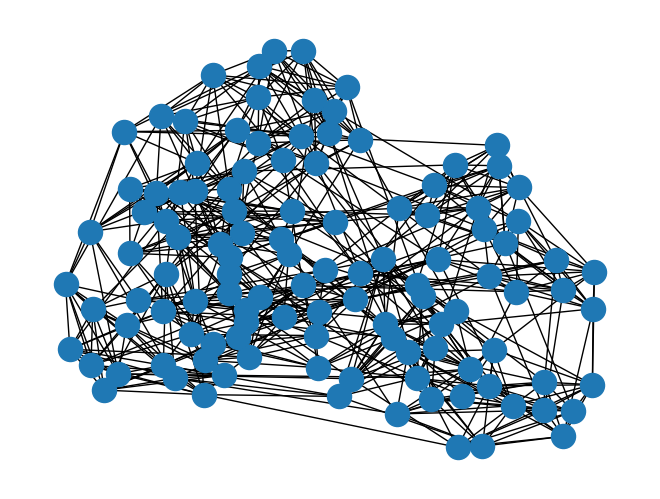

In [ ]:
import networkx as nx

# Load the graph from the GML file
file_path = "football.gml"
graph = nx.read_gml(file_path)

# Create a mapping from node labels to integers
node_mapping = {label: idx for idx, label in enumerate(graph.nodes())}

# Apply the mapping to convert node labels to integers
graph = nx.relabel_nodes(graph, node_mapping)

# Now you can work with the graph G with nodes as integers
# For example, you can print basic information about the graph
print("Nodes:", graph.nodes())
print("Edges:", graph.edges())

# You can also visualize the graph if you have matplotlib installed
import matplotlib.pyplot as plt
nx.draw(graph, with_labels=False)
plt.show()

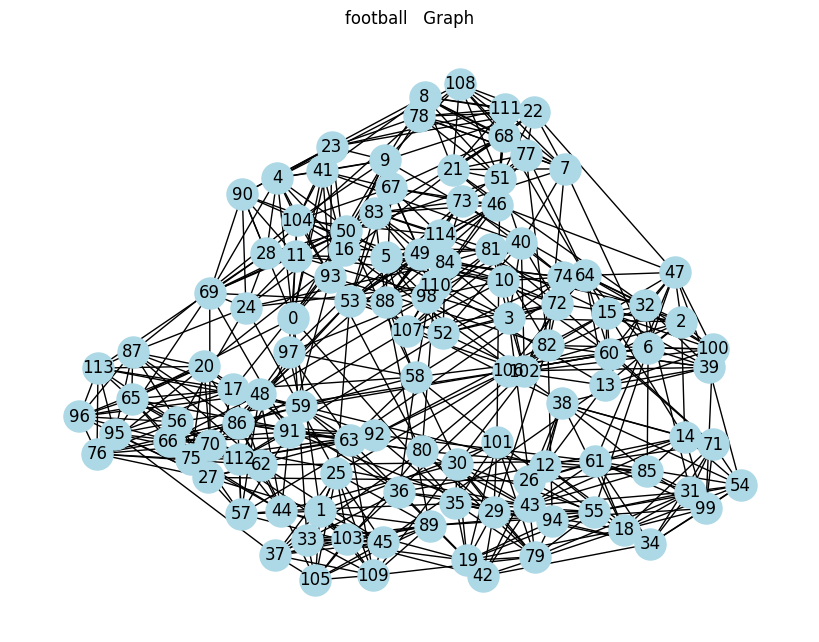

In [ ]:

# Visualize the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color="lightblue", node_size=500)
plt.title("football   Graph")
plt.show()

In [ ]:
football = file_path
football_labels = 'groundTruth.txt'

football_adj_matrix= read_gml_to_adjacency_matrix(football)

football_labels=read_labels_from_file(football_labels)


4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


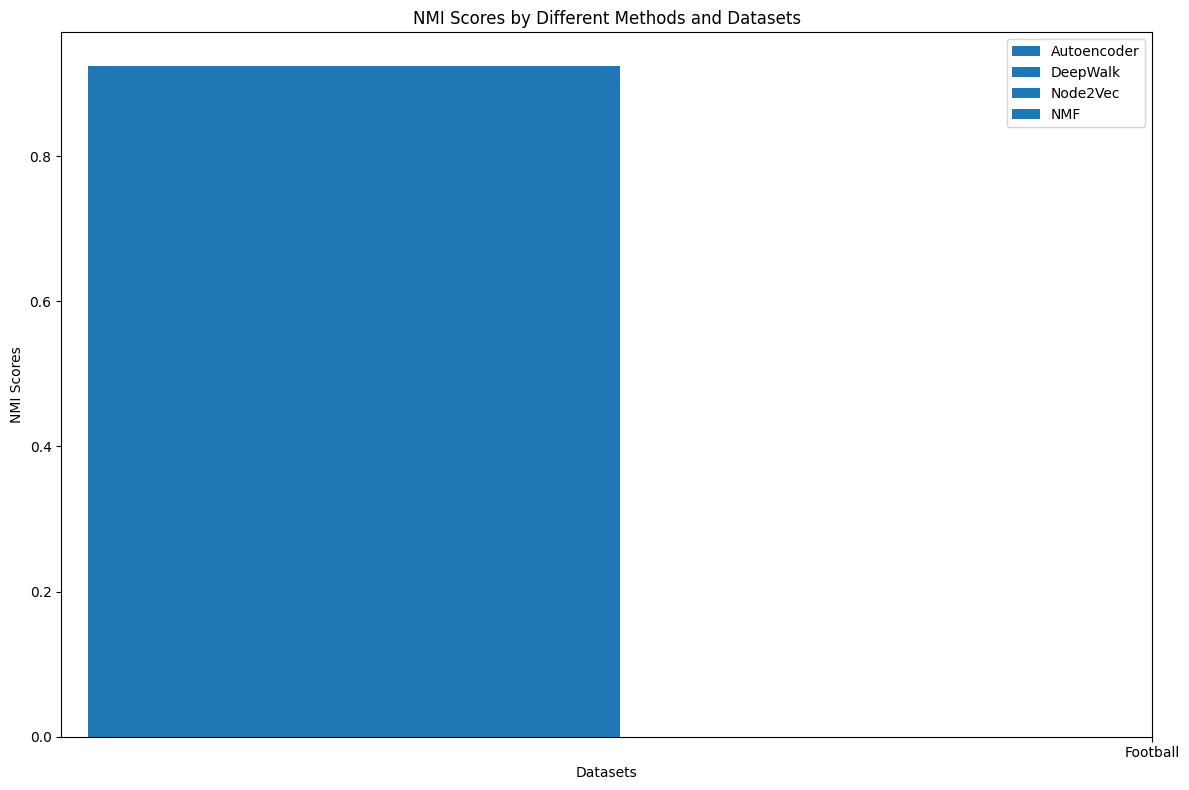

[[0.819345   1.1823727  1.0112066  ... 0.9802259  1.0117464  1.016427  ]
 [1.0055541  0.9742683  0.91764605 ... 1.2375836  1.1740165  1.161136  ]
 [1.0642673  1.0783776  0.964627   ... 0.8487296  1.022768   1.1449116 ]
 ...
 [1.0637546  1.0601817  0.97299004 ... 1.0585144  0.9340136  0.9384537 ]
 [0.91829467 0.99951565 1.0472987  ... 0.9951948  1.0079681  1.0180646 ]
 [1.0335941  0.9486761  1.0004166  ... 0.95922494 0.9415375  0.9643125 ]]


In [ ]:
from sklearn.preprocessing import normalize

# List of datasets with specific parameters
datasets = [

    {
        "name": "Football",
        "adj_matrix": football_adj_matrix,
        "labels": football_labels,
        "params": {"encoding_dim": 25, "batch_size": 30, "epochs": 380, "n_clusters": 12, "dimensions": 128}
    }
]

# Collect the NMI scores
nmi_scores = {method: [] for method in ["Autoencoder", "DeepWalk", "Node2Vec", "NMF"]}

for dataset in datasets:
    name = dataset["name"]
    adj_matrix = dataset["adj_matrix"]
    labels = dataset["labels"]
    params = dataset["params"]

    # Create the graph from adjacency matrix
    graph = nx.from_numpy_array(adj_matrix)

    # Calculate embeddings and NMI scores
    combined_matrix = combine_similarity_matrices(create_similarity_matrices(adj_matrix))

    embeddings_autoencoder = autoencoder_embeddings(combined_matrix, params["encoding_dim"], params["batch_size"], params["epochs"])
    nmi_autoencoder = calculate_nmi(embeddings_autoencoder, labels, params["n_clusters"])
    nmi_scores["Autoencoder"].append(nmi_autoencoder)


# Plot the NMI scores for each dataset
dataset_names = [dataset["name"] for dataset in datasets]
x = np.arange(len(dataset_names))
width = 0.2  # width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - 1.5 * width, nmi_scores["Autoencoder"], width, label='Autoencoder')
rects2 = ax.bar(x - 0.5 * width, nmi_scores["DeepWalk"], width, label='DeepWalk')
rects3 = ax.bar(x + 0.5 * width, nmi_scores["Node2Vec"], width, label='Node2Vec')
rects4 = ax.bar(x + 1.5 * width, nmi_scores["NMF"], width, label='NMF')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Datasets')
ax.set_ylabel('NMI Scores')
ax.set_title('NMI Scores by Different Methods and Datasets')
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.legend()

fig.tight_layout()
plt.show()
print(embeddings_autoencoder)
embeddings = embeddings_autoencoder

# subgraphing

In [ ]:
def format_labels(node_ids, community_labels):
    label_dict = {}
    for node_id, label in zip(node_ids, community_labels):
        label_dict[node_id] = label
    return label_dict


In [ ]:
import networkx as nx
import numpy as np

# Definitions

def density_i(G, i):
    ki = G.degree(i)
    density = sum(len(set(G.neighbors(i)).intersection(set(G.neighbors(j)))) / (2 * ki) for j in G.neighbors(i))
    return density

def percentile_25(S):
    return np.percentile(S, 25)

def is_core_node(density_i, percentile_25_density):
    return density_i >= percentile_25_density

def sim_ij(G, i, j):
    ki = G.degree(i)
    kj = G.degree(j)
    nij = len(set(G.neighbors(i)).intersection(set(G.neighbors(j))))
    similarity = nij / (ki + kj)
    return similarity

def sim_i_S(G, i, S):
    ki = G.degree(i)
    similarity = sum(len(set(G.neighbors(i)).intersection(S)) / ki for j in G.neighbors(i) if j in S)
    return similarity

# Algorithm 1

def select_nodes(G, k):
    NodesSet = list(G.nodes)
    density_G = [density_i(G, i) for i in NodesSet]
    percentile_25_density_G = percentile_25(density_G)
    CoreNodes = [i for i, d in zip(NodesSet, density_G) if is_core_node(d, percentile_25_density_G)]

    weights = {(i, j): (1 - sim_ij(G, i, j)) for i in G.nodes() for j in G.nodes() if G.has_edge(i, j)}

    SelectedNodes = []

    # Find the pair of core nodes with the maximum shortest path length
    u, v = max([(i, j) for i in CoreNodes for j in CoreNodes if i != j], key=lambda x: nx.shortest_path_length(G, source=x[0], target=x[1]))

    # Choose nodes u and v based on their degrees
    u_neighbors = list(G.neighbors(u)) + [u]
    v_neighbors = list(G.neighbors(v)) + [v]
    u = max(u_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))
    v = max(v_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))

    SelectedNodes.extend([u, v])

    while len(SelectedNodes) < k:
        u = max([node for node in CoreNodes if node not in SelectedNodes], key=lambda x: min(nx.shortest_path_length(G, source=x, target=j) for j in SelectedNodes))

        u_neighbors = list(G.neighbors(u)) + [u]
        u = max(u_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))
        SelectedNodes.append(u)

    return SelectedNodes[:k]




[0, 6, 19, 3, 17, 53, 7, 5, 2, 18, 1, 8, 27, 20, 29, 104, 9, 16, 23, 69, 4, 60, 72, 74, 81, 84, 98, 11, 102, 107, 10, 15, 32, 39, 45, 64, 100, 106, 110, 13, 22, 46, 51, 68, 77, 111, 21, 37, 89, 109, 25, 35, 44, 55, 79, 82, 30, 34, 43, 61, 31, 103, 105, 33, 67, 40, 93, 41, 47, 49, 66, 86, 91, 92, 48, 112, 52, 38, 14, 71, 99, 54, 62, 65, 70, 76, 87, 57]


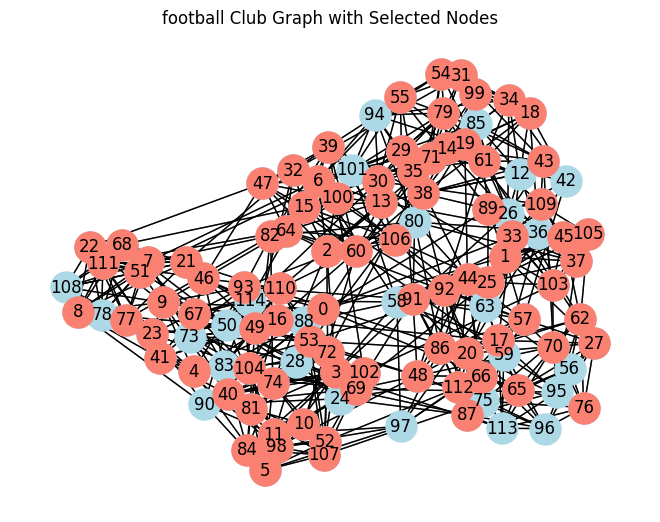

In [ ]:


# Load the Karate Club graph


# Define the number of nodes to select
k = 88

# Use the algorithm to select nodes
selected_nodes = select_nodes(graph, k)
print(selected_nodes)

# Draw the graph
pos = nx.spring_layout(graph)  # positions for all nodes

# Draw nodes
nx.draw(graph, pos, node_color='lightblue', with_labels=True, node_size=500)

# Draw selected nodes with a different color
nx.draw_networkx_nodes(graph, pos, nodelist=selected_nodes, node_color='salmon', node_size=500)

# Draw edges
nx.draw_networkx_edges(graph, pos, width=1.0, alpha=0.5)



plt.title("football Club Graph with Selected Nodes")
plt.show()


In [ ]:
set_selected_nodes=set(selected_nodes)

In [ ]:
subgraph = graph.subgraph(set_selected_nodes)

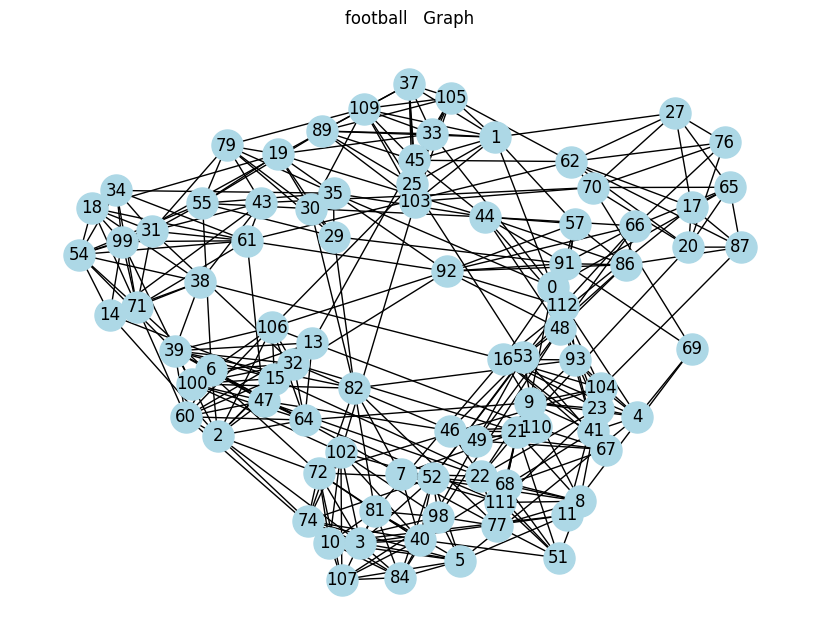

In [ ]:

# Visualize the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, with_labels=True, node_color="lightblue", node_size=500)
plt.title("football   Graph")
plt.show()

In [ ]:
import numpy as np

def embeddings_to_dict(embedding_matrix, node_ids):
    embeddings_dict = {}
    for i, node_id in enumerate(node_ids):
        embeddings_dict[node_id] = embedding_matrix[i]
    return embeddings_dict

# Example usage:
# embedding_matrix = np.random.rand(len(node_ids), embedding_dim)  # Replace with your embedding matrix
# node_ids = [0, 1, 2, 3]  # Replace with your node IDs
embeddings_dict = embeddings_to_dict(embeddings, graph.nodes())
print(embeddings_dict)


{0: array([0.819345  , 1.1823727 , 1.0112066 , 1.0755091 , 1.0884745 ,
       0.99614406, 0.89600366, 1.112985  , 1.1658738 , 0.9975803 ,
       0.88890296, 1.2669518 , 1.1000626 , 1.0208015 , 1.084928  ,
       0.9389336 , 0.9854022 , 0.9886372 , 1.0383526 , 1.0102316 ,
       1.140443  , 0.95063686, 0.9802259 , 1.0117464 , 1.016427  ],
      dtype=float32), 1: array([1.0055541 , 0.9742683 , 0.91764605, 1.0595526 , 0.80561525,
       1.026662  , 1.003187  , 1.2370347 , 1.188988  , 1.1455283 ,
       0.869395  , 0.9795979 , 1.1356388 , 1.0890846 , 1.255084  ,
       1.0995334 , 1.1066521 , 0.99731266, 0.8517171 , 1.0292404 ,
       1.0654101 , 1.1377274 , 1.2375836 , 1.1740165 , 1.161136  ],
      dtype=float32), 2: array([1.0642673 , 1.0783776 , 0.964627  , 1.1314046 , 1.0908511 ,
       0.8922627 , 1.0656624 , 1.1275573 , 0.90619904, 0.78229976,
       1.2432455 , 0.98846936, 0.90458924, 1.0230395 , 0.95603853,
       1.1622231 , 1.0856415 , 1.244923  , 1.1920233 , 1.1020509 ,
      

In [ ]:
def extract_subgraph_embedding(graph, subgraph, embedding):
    """
    Extracts embeddings of nodes in a subgraph from the embeddings of the entire graph.

    Parameters:
        graph (networkx.Graph): The entire graph.
        subgraph (networkx.Graph): The subgraph for which embeddings need to be extracted.
        embedding (dict): A dictionary containing node embeddings for the entire graph.

    Returns:
        dict: A dictionary containing node embeddings for the subgraph.
    """
    subgraph_embedding = {}
    for node in subgraph.nodes():
        # Check if the node from the subgraph exists in the embedding dictionary
        if node in embedding:
            subgraph_embedding[node] = embedding[node]
        else:
            print(f"Node {node} not found in the embedding dictionary.")

    return subgraph_embedding

In [ ]:
embeddings_dict

{0: array([0.819345  , 1.1823727 , 1.0112066 , 1.0755091 , 1.0884745 ,
        0.99614406, 0.89600366, 1.112985  , 1.1658738 , 0.9975803 ,
        0.88890296, 1.2669518 , 1.1000626 , 1.0208015 , 1.084928  ,
        0.9389336 , 0.9854022 , 0.9886372 , 1.0383526 , 1.0102316 ,
        1.140443  , 0.95063686, 0.9802259 , 1.0117464 , 1.016427  ],
       dtype=float32),
 1: array([1.0055541 , 0.9742683 , 0.91764605, 1.0595526 , 0.80561525,
        1.026662  , 1.003187  , 1.2370347 , 1.188988  , 1.1455283 ,
        0.869395  , 0.9795979 , 1.1356388 , 1.0890846 , 1.255084  ,
        1.0995334 , 1.1066521 , 0.99731266, 0.8517171 , 1.0292404 ,
        1.0654101 , 1.1377274 , 1.2375836 , 1.1740165 , 1.161136  ],
       dtype=float32),
 2: array([1.0642673 , 1.0783776 , 0.964627  , 1.1314046 , 1.0908511 ,
        0.8922627 , 1.0656624 , 1.1275573 , 0.90619904, 0.78229976,
        1.2432455 , 0.98846936, 0.90458924, 1.0230395 , 0.95603853,
        1.1622231 , 1.0856415 , 1.244923  , 1.1920233 , 1.1

In [ ]:
embedding=extract_subgraph_embedding(graph, subgraph, embeddings_dict)

In [ ]:
embedding

{0: array([0.819345  , 1.1823727 , 1.0112066 , 1.0755091 , 1.0884745 ,
        0.99614406, 0.89600366, 1.112985  , 1.1658738 , 0.9975803 ,
        0.88890296, 1.2669518 , 1.1000626 , 1.0208015 , 1.084928  ,
        0.9389336 , 0.9854022 , 0.9886372 , 1.0383526 , 1.0102316 ,
        1.140443  , 0.95063686, 0.9802259 , 1.0117464 , 1.016427  ],
       dtype=float32),
 1: array([1.0055541 , 0.9742683 , 0.91764605, 1.0595526 , 0.80561525,
        1.026662  , 1.003187  , 1.2370347 , 1.188988  , 1.1455283 ,
        0.869395  , 0.9795979 , 1.1356388 , 1.0890846 , 1.255084  ,
        1.0995334 , 1.1066521 , 0.99731266, 0.8517171 , 1.0292404 ,
        1.0654101 , 1.1377274 , 1.2375836 , 1.1740165 , 1.161136  ],
       dtype=float32),
 2: array([1.0642673 , 1.0783776 , 0.964627  , 1.1314046 , 1.0908511 ,
        0.8922627 , 1.0656624 , 1.1275573 , 0.90619904, 0.78229976,
        1.2432455 , 0.98846936, 0.90458924, 1.0230395 , 0.95603853,
        1.1622231 , 1.0856415 , 1.244923  , 1.1920233 , 1.1

## subgraph clustring

In [ ]:



import numpy as np
from sklearn.cluster import SpectralClustering
import networkx as nx

def spectral_clustering_with_embeddings(graph, embeddings, num_clusters):
    # Convert embeddings dictionary values to a numpy array
    embedding_matrix = np.array(list(embeddings.values()))

    # Compute the affinity matrix based on embeddings
    affinity_matrix = np.dot(embedding_matrix, embedding_matrix.T)

    # Apply spectral clustering
    spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed')
    cluster_labels = spectral.fit_predict(affinity_matrix)

    # Create a dictionary to store node-cluster mappings
    node_cluster_map = {}
    for i, label in enumerate(cluster_labels):
        # Get the node label from the original graph
        node_label = list(graph.nodes())[i]
        # Store the mapping of node to its cluster label
        node_cluster_map[node_label] = label

    return node_cluster_map

# Example usage:
# graph = nx.Graph()
# graph.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])
# embeddings = np.random.rand(graph.number_of_nodes(), 64)  # Replace with your actual embeddings
num_clusters = 12
clusters = spectral_clustering_with_embeddings(subgraph, embedding, num_clusters)
print(clusters)
eff=clusters


{0: 1, 1: 8, 2: 2, 3: 1, 4: 1, 5: 1, 6: 2, 7: 10, 8: 10, 9: 10, 10: 1, 11: 1, 13: 2, 14: 5, 15: 2, 16: 1, 17: 9, 18: 5, 19: 0, 20: 9, 21: 10, 22: 10, 23: 1, 25: 8, 27: 9, 29: 0, 30: 0, 31: 5, 32: 2, 33: 8, 34: 5, 35: 0, 37: 8, 38: 5, 39: 2, 40: 1, 41: 6, 43: 5, 44: 4, 45: 8, 46: 1, 47: 2, 48: 4, 49: 7, 51: 10, 52: 1, 53: 2, 54: 5, 55: 0, 57: 4, 60: 2, 61: 5, 62: 9, 64: 2, 65: 9, 66: 4, 67: 1, 68: 10, 69: 1, 70: 9, 71: 5, 72: 1, 74: 2, 76: 9, 77: 10, 79: 0, 81: 1, 82: 1, 84: 1, 86: 4, 87: 9, 89: 8, 91: 4, 92: 4, 93: 3, 98: 1, 99: 5, 100: 2, 102: 11, 103: 8, 104: 1, 105: 8, 106: 2, 107: 1, 109: 8, 110: 2, 111: 10, 112: 4}


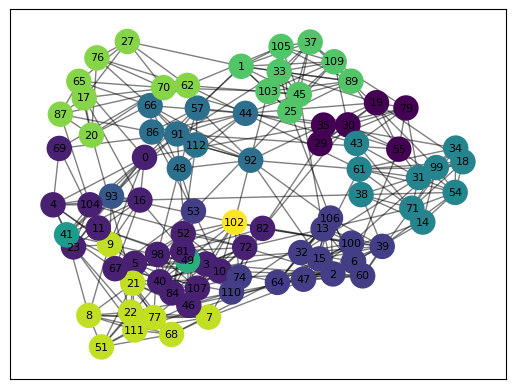

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = subgraph  # Assuming graph is defined somewhere

# Add nodes to the graph
nodes_clusters = clusters  # Assuming community_structure is defined somewhere

# Add nodes with colors based on clusters
colors = [nodes_clusters[node] for node in G.nodes]
nx.set_node_attributes(G, colors, 'color')

# Plot the graph
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.viridis)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, labels={node: node for node in G.nodes}, font_size=8)  # Display node IDs
plt.show()


# generalisation : label propagation

In [ ]:
def common_neighbors(G, u, v):
    return len(set(G.neighbors(u)).intersection(set(G.neighbors(v))))


def CommunityDetection(G, num, SelectedCoreNodes):

    # Initialize variables and data structures
    UnusedLabeledNodes = SelectedCoreNodes.copy()
    UsedLabeledNodes = set()
    solution={}
    print('satge 1')
    # Stage 1: Labeling the selected core nodes
    for node, label in SelectedCoreNodes.items():
        UnusedLabeledNodes[node] = label

    UnusedLabeledNodes = dict(sorted(UnusedLabeledNodes.items(), key=lambda item: density_i(G, item[0]), reverse=True))
    print(UnusedLabeledNodes)
    print('satge 2')
    # Stage 2: Expanding labeled core nodes with label propagation
    print(UnusedLabeledNodes)
    while UnusedLabeledNodes:


        u, lu = UnusedLabeledNodes.popitem()


        for v in G.neighbors(u):

            if v not in UsedLabeledNodes and common_neighbors(G, u, v) >= (G.degree(v) ) /2:
                UnusedLabeledNodes[v] = lu

        solution[u]=lu
        UsedLabeledNodes.add(u)


    print('satge 3')
    # Stage 3: Labeling the rest of the unlabeled nodes
    UnlabeledNodes = set(G.nodes()) - {u for u  in UsedLabeledNodes}

    while UnlabeledNodes:
        p = max(UnlabeledNodes, key=lambda v: max(
            (sum(1 for u in G.neighbors(v) if (u in UsedLabeledNodes and solution[u] == l)) /
             G.degree(v)) for l in range(1, num + 1)))
        lp = max(range(1, num + 1), key=lambda l: sum(
            1 for u in G.neighbors(p) if (u in UsedLabeledNodes and solution[u] == l)))
        UsedLabeledNodes.add((p, lp))
        solution[p]=lp
        UnlabeledNodes.remove(p)

    return solution


In [ ]:
# Define the SelectedCoreNodes dictionary
#SelectedCoreNodes = format_labels(selected_nodes,cluster_labels)


# Call the CommunityDetection function with the network and the SelectedCoreNodes dictionary
print('hi1',eff)
community_structure = CommunityDetection(graph,12, eff)

# community_structure will contain the labeled nodes representing the community structure of the network


hi1 {0: 1, 1: 8, 2: 2, 3: 1, 4: 1, 5: 1, 6: 2, 7: 10, 8: 10, 9: 10, 10: 1, 11: 1, 13: 2, 14: 5, 15: 2, 16: 1, 17: 9, 18: 5, 19: 0, 20: 9, 21: 10, 22: 10, 23: 1, 25: 8, 27: 9, 29: 0, 30: 0, 31: 5, 32: 2, 33: 8, 34: 5, 35: 0, 37: 8, 38: 5, 39: 2, 40: 1, 41: 6, 43: 5, 44: 4, 45: 8, 46: 1, 47: 2, 48: 4, 49: 7, 51: 10, 52: 1, 53: 2, 54: 5, 55: 0, 57: 4, 60: 2, 61: 5, 62: 9, 64: 2, 65: 9, 66: 4, 67: 1, 68: 10, 69: 1, 70: 9, 71: 5, 72: 1, 74: 2, 76: 9, 77: 10, 79: 0, 81: 1, 82: 1, 84: 1, 86: 4, 87: 9, 89: 8, 91: 4, 92: 4, 93: 3, 98: 1, 99: 5, 100: 2, 102: 11, 103: 8, 104: 1, 105: 8, 106: 2, 107: 1, 109: 8, 110: 2, 111: 10, 112: 4}
satge 1
{105: 8, 33: 8, 103: 8, 49: 7, 67: 1, 37: 8, 45: 8, 46: 1, 109: 8, 22: 10, 25: 8, 89: 8, 110: 2, 53: 2, 29: 0, 1: 8, 41: 6, 30: 0, 8: 10, 9: 10, 51: 10, 68: 10, 77: 10, 111: 10, 79: 0, 93: 3, 21: 10, 23: 1, 54: 5, 19: 0, 35: 0, 7: 10, 16: 1, 39: 2, 55: 0, 76: 9, 4: 1, 2: 2, 5: 1, 10: 1, 18: 5, 104: 1, 106: 2, 71: 5, 100: 2, 0: 1, 15: 2, 13: 2, 47: 2, 60: 2, 

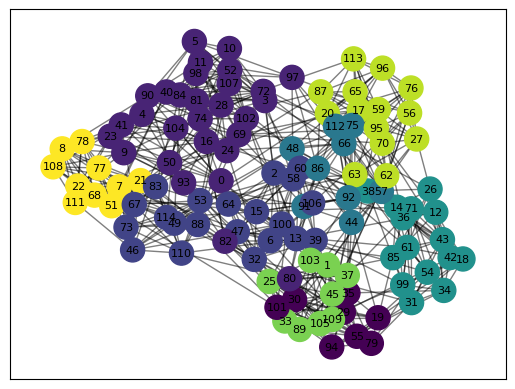

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = graph  # Assuming graph is defined somewhere

# Add nodes to the graph
nodes_clusters = community_structure  # Assuming community_structure is defined somewhere

# Add nodes with colors based on clusters
colors = [nodes_clusters[node] for node in G.nodes]
nx.set_node_attributes(G, colors, 'color')

# Plot the graph
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.viridis)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, labels={node: node for node in G.nodes}, font_size=8)  # Display node IDs
plt.show()


In [ ]:
cluster_dict =community_structure

cluster_list = [cluster_dict[node] for node in sorted(cluster_dict.keys())]



# result

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
ground_truth_labels = """
7
0
2
3
7
3
2
8
8
7
3
10
6
2
6
2
7
9
6
1
9
8
8
7
10
0
6
9
11
1
1
6
2
0
6
1
5
0
6
2
3
7
5
6
4
0
11
2
4
11
10
8
3
11
6
1
9
4
11
10
2
6
9
10
2
9
4
11
8
10
9
6
3
11
3
4
9
8
8
1
5
3
5
11
3
6
4
9
11
0
5
4
4
7
1
9
9
10
3
6
2
1
3
0
7
0
2
3
8
0
4
8
4
9
11
"""


# Convert ground truth labels to a list of integers
ground_truth_labels = [int(label) for label in ground_truth_labels.strip().split('\n')]
ground_truth_labels = [int(label) for label in ground_truth_labels]

# Define the two sets of cluster labels
cluster_labels1 = cluster_list
cluster_labels2 = ground_truth_labels


# If cluster_labels2 is nested, flatten it
if isinstance(cluster_labels2[0], list):
    cluster_labels2 = [label for sublist in cluster_labels2 for label in sublist]

# Compute NMI
nmi = normalized_mutual_info_score(cluster_labels1, cluster_labels2)

print("Normalized Mutual Information (NMI):", nmi)


Normalized Mutual Information (NMI): 0.8365619880500388


# test polbooks

In [ ]:
graph = 'polbooks.gml'
ground = '/content/groundTruth (2) .txt'

polbooks = graph
polbooks_labels = ground




Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104]
Edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 3), (1, 5), (1, 6), (2, 4), (2, 5), (2, 7), (3, 5), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20), (3, 21), (3, 22), (3, 23), (3, 24), (3, 25), (3, 26), (3, 27), (4, 5), (4, 6), (4, 28), (4, 29), (4, 30), (4, 31), (5, 6), (5, 7), (6, 7), (6, 10), (6, 12), (6, 18), (6, 22), (6, 25), (6, 29), (7, 14), (7, 30), (7, 58), (7, 71), (7, 85), (8, 9), (8, 10), (8, 11), (8, 12), (8, 13), (8, 14), (8, 20), (8, 21), (8, 22), (8, 23), (8, 24), (8, 26), (8, 2

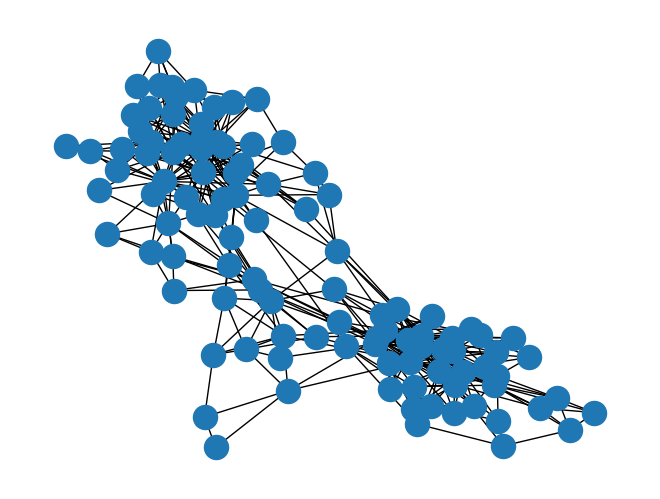

In [ ]:
import networkx as nx

# Load the graph from the GML file
file_path = "polbooks.gml"
graph = nx.read_gml(file_path)

# Create a mapping from node labels to integers
node_mapping = {label: idx for idx, label in enumerate(graph.nodes())}

# Apply the mapping to convert node labels to integers
graph = nx.relabel_nodes(graph, node_mapping)

# Now you can work with the graph G with nodes as integers
# For example, you can print basic information about the graph
print("Nodes:", graph.nodes())
print("Edges:", graph.edges())

# You can also visualize the graph if you have matplotlib installed
import matplotlib.pyplot as plt
nx.draw(graph, with_labels=False)
plt.show()

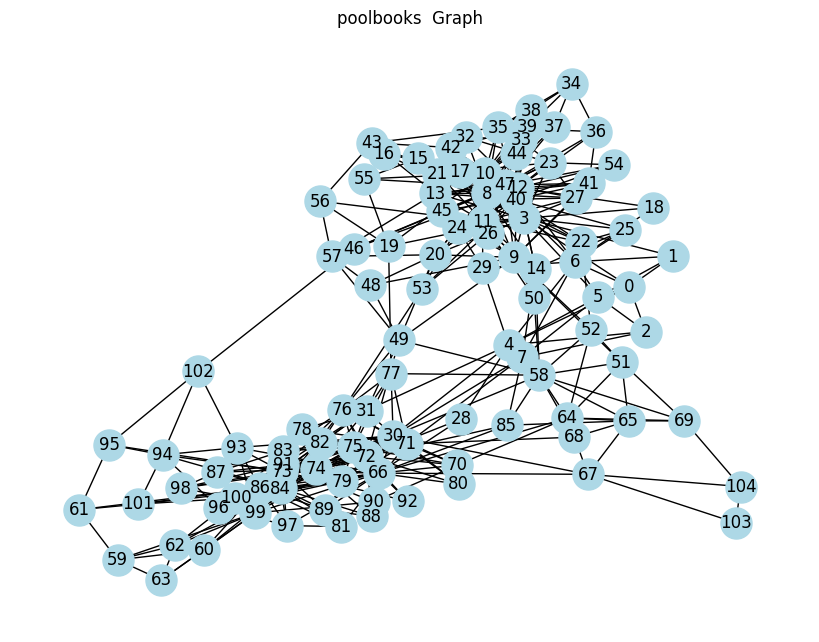

In [ ]:

# Visualize the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color="lightblue", node_size=500)
plt.title("poolbooks  Graph")
plt.show()

In [ ]:

polbooks_adj_matrix= read_gml_to_adjacency_matrix(polbooks)



polbooks_labels=read_labels_from_file(polbooks_labels)



4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


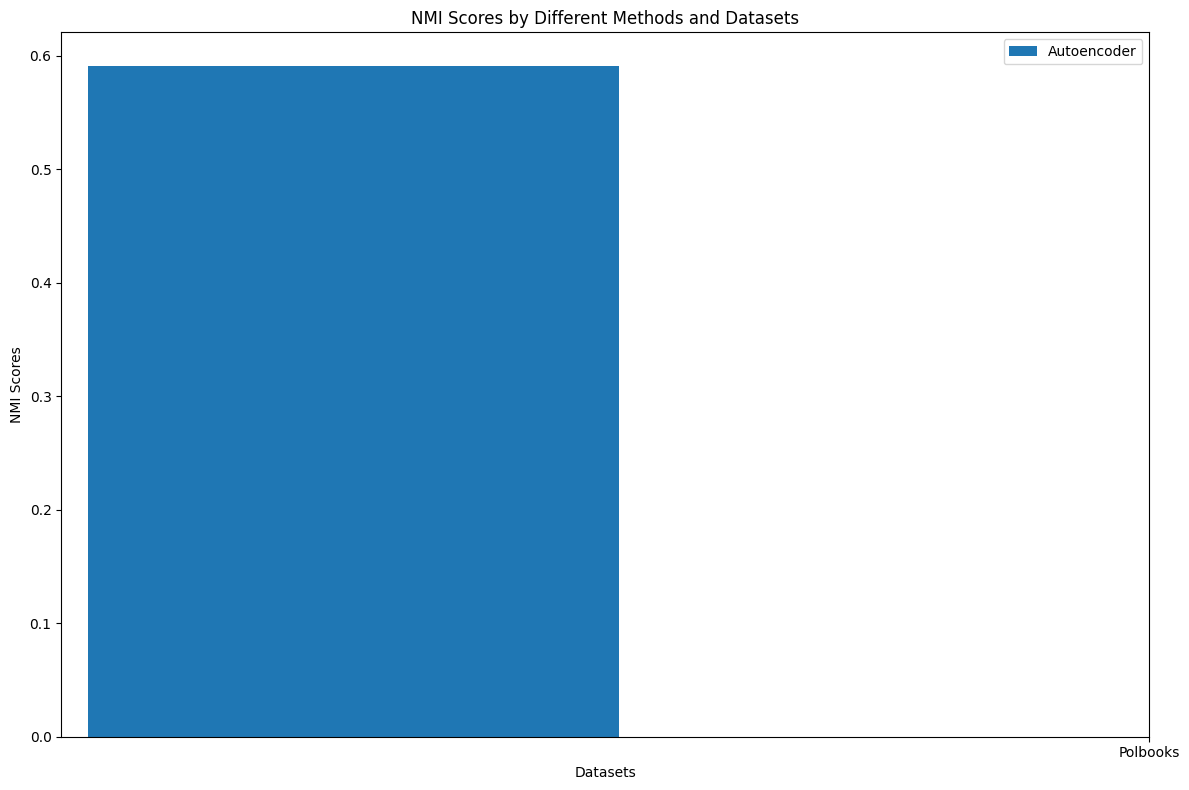

[[0.85996544 0.71552056 0.7320014  ... 1.0571775  0.8148668  1.1975222 ]
 [1.0184462  0.86457527 0.4880822  ... 0.78904426 0.7418907  1.1086447 ]
 [0.15646356 0.5251753  0.68053806 ... 1.056723   1.0891223  0.77933615]
 ...
 [0.27473086 0.942409   0.51428175 ... 0.63147223 0.6923031  0.67448056]
 [1.4755249  0.75728935 0.         ... 0.15929532 0.         0.7502999 ]
 [1.2818954  0.7932981  0.         ... 0.4407891  0.43576592 1.1846795 ]]


In [ ]:
from sklearn.preprocessing import normalize

# List of datasets with specific parameters
datasets = [

   {
        "name": "Polbooks",
        "adj_matrix": polbooks_adj_matrix,
        "labels": polbooks_labels,
        "params": {"encoding_dim": 32, "batch_size": 20, "epochs": 410, "n_clusters": 3, "dimensions": 128}
    }
]

# Collect the NMI scores
nmi_scores = {method: [] for method in ["Autoencoder"]}

for dataset in datasets:
    name = dataset["name"]
    adj_matrix = dataset["adj_matrix"]
    labels = dataset["labels"]
    params = dataset["params"]

    # Create the graph from adjacency matrix
    graph = nx.from_numpy_array(adj_matrix)

    # Calculate embeddings and NMI scores
    combined_matrix = combine_similarity_matrices(create_similarity_matrices(adj_matrix))

    embeddings_autoencoder = autoencoder_embeddings(combined_matrix, params["encoding_dim"], params["batch_size"], params["epochs"])
    nmi_autoencoder = calculate_nmi(embeddings_autoencoder, labels, params["n_clusters"])
    nmi_scores["Autoencoder"].append(nmi_autoencoder)


# Plot the NMI scores for each dataset
dataset_names = [dataset["name"] for dataset in datasets]
x = np.arange(len(dataset_names))
width = 0.2  # width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - 1.5 * width, nmi_scores["Autoencoder"], width, label='Autoencoder')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Datasets')
ax.set_ylabel('NMI Scores')
ax.set_title('NMI Scores by Different Methods and Datasets')
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.legend()

fig.tight_layout()
plt.show()
print(embeddings_autoencoder)
embeddings = embeddings_autoencoder

[35, 99, 3, 58, 4, 8, 12, 9, 40, 72, 84, 73, 6, 5, 0, 1, 7, 2, 11, 10, 47, 13, 26, 14, 15, 16, 17, 20, 23, 21]


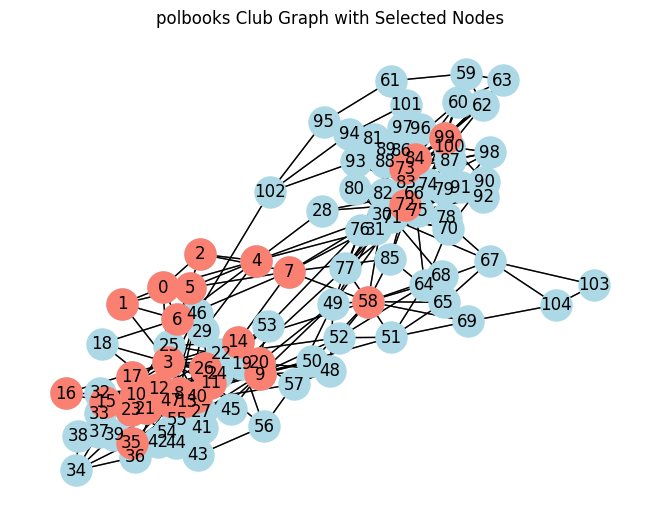

In [ ]:


# Load the Karate Club graph


# Define the number of nodes to select
k = 30

# Use the algorithm to select nodes
selected_nodes = select_nodes(graph, k)
print(selected_nodes)

# Draw the graph
pos = nx.spring_layout(graph)  # positions for all nodes

# Draw nodes
nx.draw(graph, pos, node_color='lightblue', with_labels=True, node_size=500)

# Draw selected nodes with a different color
nx.draw_networkx_nodes(graph, pos, nodelist=selected_nodes, node_color='salmon', node_size=500)

# Draw edges
nx.draw_networkx_edges(graph, pos, width=1.0, alpha=0.5)



plt.title("polbooks Club Graph with Selected Nodes")
plt.show()


In [ ]:
set_selected_nodes=set(selected_nodes)

In [ ]:
subgraph = graph.subgraph(set_selected_nodes)

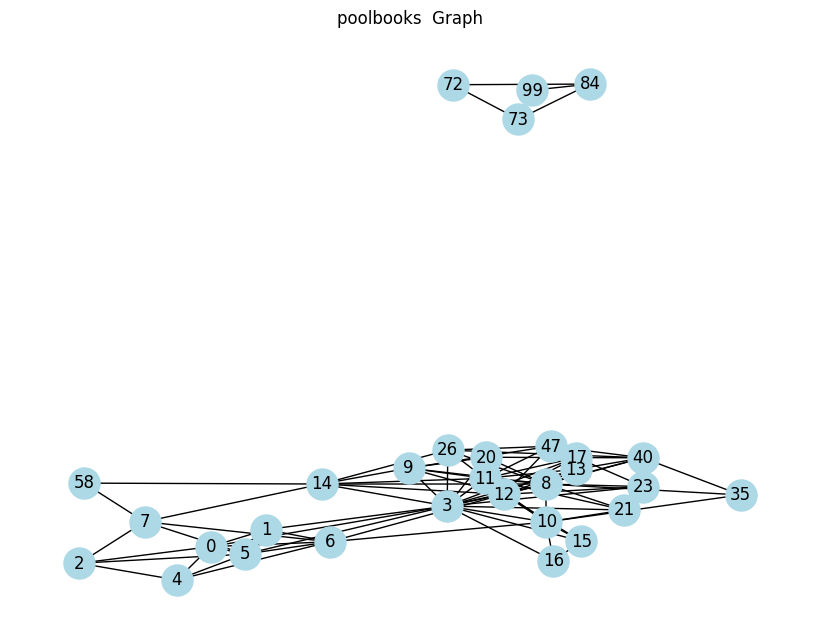

In [ ]:

# Visualize the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, with_labels=True, node_color="lightblue", node_size=500)
plt.title("poolbooks  Graph")
plt.show()

In [ ]:
import numpy as np


# Example usage:
# embedding_matrix = np.random.rand(len(node_ids), embedding_dim)  # Replace with your embedding matrix
# node_ids = [0, 1, 2, 3]  # Replace with your node IDs
embeddings_dict = embeddings_to_dict(embeddings, graph.nodes())
print(embeddings_dict)


{0: array([0.85996544, 0.71552056, 0.7320014 , 1.2076634 , 1.5184565 ,
       1.4002342 , 0.04572649, 0.7649062 , 0.42941993, 0.3304352 ,
       1.8132613 , 0.        , 0.80538553, 1.4231642 , 0.69037503,
       0.12460832, 1.1708058 , 1.3940399 , 1.0115294 , 0.97939277,
       1.1969488 , 0.8743425 , 0.35831958, 0.86834687, 0.51939535,
       0.5223643 , 0.46923107, 0.        , 0.87618923, 1.0571775 ,
       0.8148668 , 1.1975222 ], dtype=float32), 1: array([1.0184462 , 0.86457527, 0.4880822 , 1.2825849 , 1.4884136 ,
       1.3079917 , 0.        , 0.79069406, 0.45455286, 0.37610972,
       1.9780616 , 0.12060158, 0.6344403 , 1.4488534 , 0.4162938 ,
       0.27293777, 1.0400124 , 1.5843002 , 1.1490259 , 1.2163603 ,
       1.224991  , 0.72479403, 0.01774539, 1.0471716 , 0.5343436 ,
       0.4429702 , 0.5433558 , 0.        , 0.9344034 , 0.78904426,
       0.7418907 , 1.1086447 ], dtype=float32), 2: array([0.15646356, 0.5251753 , 0.68053806, 0.8783364 , 1.3880746 ,
       1.1059859 , 0.68

In [ ]:
embedding=extract_subgraph_embedding(graph, subgraph, embeddings_dict)

In [ ]:
num_clusters = 3
clusters = spectral_clustering_with_embeddings(subgraph, embedding, num_clusters)
print(clusters)
eff=clusters

{0: 1, 1: 1, 2: 1, 3: 2, 4: 1, 5: 1, 6: 1, 7: 1, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 1, 17: 2, 20: 2, 21: 2, 23: 2, 26: 2, 35: 2, 40: 2, 47: 2, 58: 0, 72: 0, 73: 0, 84: 0, 99: 0}


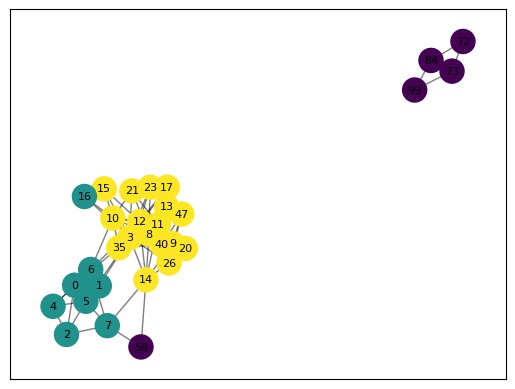

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = subgraph  # Assuming graph is defined somewhere

# Add nodes to the graph
nodes_clusters = clusters  # Assuming community_structure is defined somewhere

# Add nodes with colors based on clusters
colors = [nodes_clusters[node] for node in G.nodes]
nx.set_node_attributes(G, colors, 'color')

# Plot the graph
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.viridis)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, labels={node: node for node in G.nodes}, font_size=8)  # Display node IDs
plt.show()


In [ ]:
def common_neighbors(G, u, v):
    return len(set(G.neighbors(u)).intersection(set(G.neighbors(v))))


def CommunityDetection(G, num, SelectedCoreNodes):

    # Initialize variables and data structures
    UnusedLabeledNodes = SelectedCoreNodes.copy()
    UsedLabeledNodes = set()
    solution={}
    print('satge 1')
    # Stage 1: Labeling the selected core nodes
    for node, label in SelectedCoreNodes.items():
        UnusedLabeledNodes[node] = label

    UnusedLabeledNodes = dict(sorted(UnusedLabeledNodes.items(), key=lambda item: density_i(G, item[0]), reverse=True))
    print(UnusedLabeledNodes)
    print('satge 2')
    # Stage 2: Expanding labeled core nodes with label propagation
    print(UnusedLabeledNodes)
    while UnusedLabeledNodes:


        u, lu = UnusedLabeledNodes.popitem()


        for v in G.neighbors(u):

            if v not in UsedLabeledNodes and common_neighbors(G, u, v) >= (G.degree(v) ) / 3:
                UnusedLabeledNodes[v] = lu

        solution[u]=lu
        UsedLabeledNodes.add(u)


    print('satge 3')
    # Stage 3: Labeling the rest of the unlabeled nodes
    UnlabeledNodes = set(G.nodes()) - {u for u  in UsedLabeledNodes}

    while UnlabeledNodes:
        p = max(UnlabeledNodes, key=lambda v: max(
            (sum(1 for u in G.neighbors(v) if (u in UsedLabeledNodes and solution[u] == l)) /
             G.degree(v)) for l in range(1, num + 1)))
        lp = max(range(1, num + 1), key=lambda l: sum(
            1 for u in G.neighbors(p) if (u in UsedLabeledNodes and solution[u] == l)))
        UsedLabeledNodes.add((p, lp))
        solution[p]=lp
        UnlabeledNodes.remove(p)

    return solution


In [ ]:
# Define the SelectedCoreNodes dictionary
#SelectedCoreNodes = format_labels(selected_nodes,cluster_labels)


# Call the CommunityDetection function with the network and the SelectedCoreNodes dictionary
print('hi1',eff)
community_structure = CommunityDetection(graph,3, eff)

# community_structure will contain the labeled nodes representing the community structure of the network


hi1 {0: 1, 1: 1, 2: 1, 3: 2, 4: 1, 5: 1, 6: 1, 7: 1, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 1, 17: 2, 20: 2, 21: 2, 23: 2, 26: 2, 35: 2, 40: 2, 47: 2, 58: 0, 72: 0, 73: 0, 84: 0, 99: 0}
satge 1
{84: 0, 73: 0, 8: 2, 12: 2, 72: 0, 11: 2, 40: 2, 47: 2, 3: 2, 9: 2, 99: 0, 10: 2, 26: 2, 13: 2, 23: 2, 17: 2, 20: 2, 14: 2, 21: 2, 35: 2, 5: 1, 0: 1, 15: 2, 1: 1, 58: 0, 2: 1, 16: 1, 6: 1, 4: 1, 7: 1}
satge 2
{84: 0, 73: 0, 8: 2, 12: 2, 72: 0, 11: 2, 40: 2, 47: 2, 3: 2, 9: 2, 99: 0, 10: 2, 26: 2, 13: 2, 23: 2, 17: 2, 20: 2, 14: 2, 21: 2, 35: 2, 5: 1, 0: 1, 15: 2, 1: 1, 58: 0, 2: 1, 16: 1, 6: 1, 4: 1, 7: 1}
satge 3


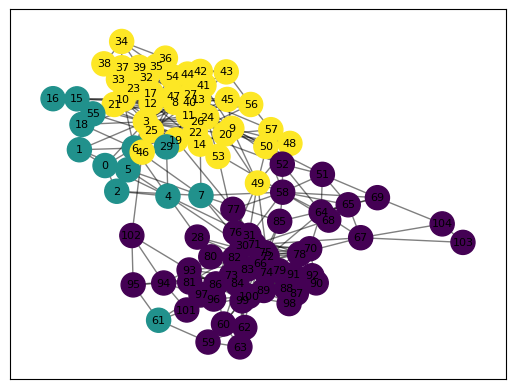

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = graph  # Assuming graph is defined somewhere

# Add nodes to the graph
nodes_clusters = community_structure  # Assuming community_structure is defined somewhere

# Add nodes with colors based on clusters
colors = [nodes_clusters[node] for node in G.nodes]
nx.set_node_attributes(G, colors, 'color')

# Plot the graph
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.viridis)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, labels={node: node for node in G.nodes}, font_size=8)  # Display node IDs
plt.show()


In [ ]:
cluster_dict =community_structure

cluster_list = [cluster_dict[node] for node in sorted(cluster_dict.keys())]



In [ ]:
from sklearn.metrics import normalized_mutual_info_score
ground_truth_labels = """
0
1
1
1
0
1
0
0
1
1
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
1
1
1
0
1
2
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
0
1
0
1
1
0
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
0
2
2
2
2
2
2
0
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
0
0
"""


# Convert ground truth labels to a list of integers
ground_truth_labels = [int(label) for label in ground_truth_labels.strip().split('\n')]
ground_truth_labels = [int(label) for label in ground_truth_labels]

# Define the two sets of cluster labels
cluster_labels1 = cluster_list
cluster_labels2 = ground_truth_labels


# If cluster_labels2 is nested, flatten it
if isinstance(cluster_labels2[0], list):
    cluster_labels2 = [label for sublist in cluster_labels2 for label in sublist]

# Compute NMI
nmi = normalized_mutual_info_score(cluster_labels1, cluster_labels2)

print("Normalized Mutual Information (NMI):", nmi)


Normalized Mutual Information (NMI): 0.5230821321206632
